This notebook is used to demonstrate the JAX implementation of Mixture Density Network (MDN) developed by [Bishop (1994)](https://publications.aston.ac.uk/id/eprint/373/1/NCRG_94_004.pdf).

The following example is revised from [this notebook](https://github.com/hardmaru/mdn_jax_tutorial/blob/master/mixture_density_networks_jax.ipynb).

In [65]:
import jax
import jax.numpy as jnp
from jax.nn import logsumexp

import optax
import equinox as eqx
from equinox.nn import MLP, Identity, Linear

import numpy as np

from typing import Callable

import matplotlib.pyplot as plt


# JAX Implementation of MDN

In [28]:
class MDN(eqx.Module):
    m: eqx.Module
    m_α: eqx.Module
    m_μ: eqx.Module
    m_σ: eqx.Module
    pdf_func: Callable
    cdf_func: Callable
    
    def __init__(self, n_input, n_hidden, n_mixture, key, **mlp_kwargs):
        key1, key2, key3, key4 = jax.random.split(key,4)
        
        # MLP model for predicting the hidden states
        # n_mlp_output = (n_output+2) * n_mixture
        self.m = MLP(in_size=n_input, out_size=n_hidden, key=key1, **mlp_kwargs)
        
        # MLP model for predicting α, μ, and σ
        self.m_α = Linear(in_features=n_hidden, out_features=n_mixture, key=key2)
        self.m_μ = Linear(in_features=n_hidden, out_features=n_mixture, key=key3)
        self.m_σ = Linear(in_features=n_hidden, out_features=n_mixture, key=key4)
        
        # PDF function of mixture distributions 
        self.pdf_func = jax.scipy.stats.norm.pdf
        
        # CDF function of mixture distributions 
        self.cdf_func = jax.scipy.stats.norm.cdf
    
    def __call__(self, x):
        # Calculate the weights, mean, and standard deviation of the mixture distributions
        z = self.m(x)  # shape: (n_hidden,)
        z_α, z_μ, z_σ = self.m_α(z), self.m_μ(z), self.m_σ(z) # shape: (n_mixture,) (n_mixture,) (n_mixture)
        
        # The weights (n_mixture,)
        α = jax.nn.softmax(z_α)
        
        # The mean (n_mixture,)
        μ = z_μ
        
        # The standard deviation (n_mixture,)
        σ = jnp.exp(z_σ)
        
        return α, μ, σ
    
    def pdf(self, y, x):
        α, μ, σ = self.__call__(x)
        pdfs = jax.vmap(self.pdf_func, in_axes=(None,0,0))(y, μ, σ)
        return jnp.sum(jnp.dot(α, pdfs))
    
    def cdf(self, y, x):
        α, μ, σ = self.__call__(x)
        cdfs = jax.vmap(self.cdf_func, in_axes=(None,0,0))(y, μ, σ)
        return jnp.sum(jnp.dot(α, cdfs))


In [43]:
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}

model = MDN(n_input, n_hidden, n_mixture, key, **mlp_kwargs)
model.cdf(jnp.array([1.5]), jnp.array([1.5]))


Array(0.932729, dtype=float32)

# Loss function

In [72]:
logSqrtTwoPI = jnp.log(jnp.sqrt(2.0 * jnp.pi))

def lognormal(y, μ, σ):
    return -0.5 * ((y - μ) / σ) ** 2 - jnp.log(σ) - logSqrtTwoPI

def loss_per_sample(model, x, y):
    α, μ, σ = model(x)
    # α = α - logsumexp(α, 1, keepdims=True)
    α = α - logsumexp(α)
    v = α + lognormal(y, μ, σ)
    v = logsumexp(v)
    return v

def loss_func(model, x, y):
    v = jax.vmap(loss_per_sample, in_axes=(None,0,0))(model, x, y)
    return -np.mean(v)


# Simple example (from Biship (1994))

In [78]:
def generate_data(n_samples):
    epsilon = np.random.normal(size=(n_samples))
    x_data = np.random.uniform(-10.5, 10.5, n_samples)
    y_data = 7*jnp.sin(0.75*x_data) + 0.5*x_data + epsilon
    return x_data, y_data
  
n_samples = batch_size = 1000 # just use train everything in a batch
x_data, y_data = generate_data(n_samples)
x_data = jnp.array(x_data.reshape(batch_size, 1))
y_data = jnp.array(y_data.reshape(batch_size, 1))

x_test_data = jnp.linspace(-15, 15, n_samples).reshape(batch_size, 1)


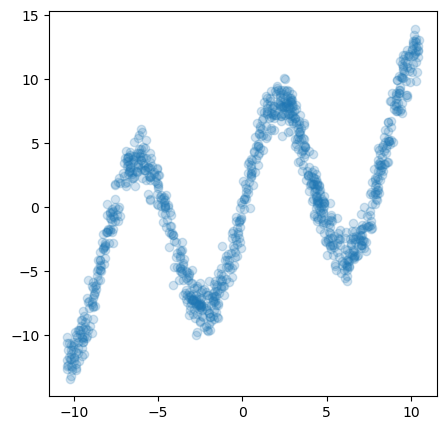

In [48]:
plt.figure(figsize=(5, 5))
plt.scatter(x_data, y_data, alpha=0.2)
plt.show()


# Train MDN

In [50]:
# from jax.example_libraries import optimizers

In [53]:
# step_size = 0.01
# opt_init, opt_update, get_params = optimizers.adam(step_size)
# opt_state = opt_init(model)


In [88]:
learning_rate = 0.01
steps = 3000

mdn_y_data, mdn_x_data = x_data, y_data


In [89]:
@eqx.filter_jit
def make_step(model, x, y, opt_state):
    loss, grads = eqx.filter_value_and_grad(loss_func)(model, x, y)
    updates, opt_state = optim.update(
        grads, opt_state, eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

optim = optax.adam(learning_rate)
opt_state = optim.init(eqx.filter(model, eqx.is_array))
for step in range(steps):
    loss, model, opt_state = make_step(model, mdn_x_data, mdn_y_data, opt_state)
    loss = loss.item()
    if step % 300 == 0:
        print(f"step={step}, loss={loss}")


step=0, loss=46.516822814941406
step=300, loss=2.1531221866607666
step=600, loss=1.7162466049194336
step=900, loss=1.5975810289382935
step=1200, loss=1.7307820320129395
step=1500, loss=1.5073784589767456
step=1800, loss=1.4763258695602417
step=2100, loss=1.5226011276245117
step=2400, loss=1.4838991165161133
step=2700, loss=1.4433118104934692


# Reproduce the simple example

In [90]:
α_data, μ_data, σ_data = jax.vmap(model)(x_test_data)

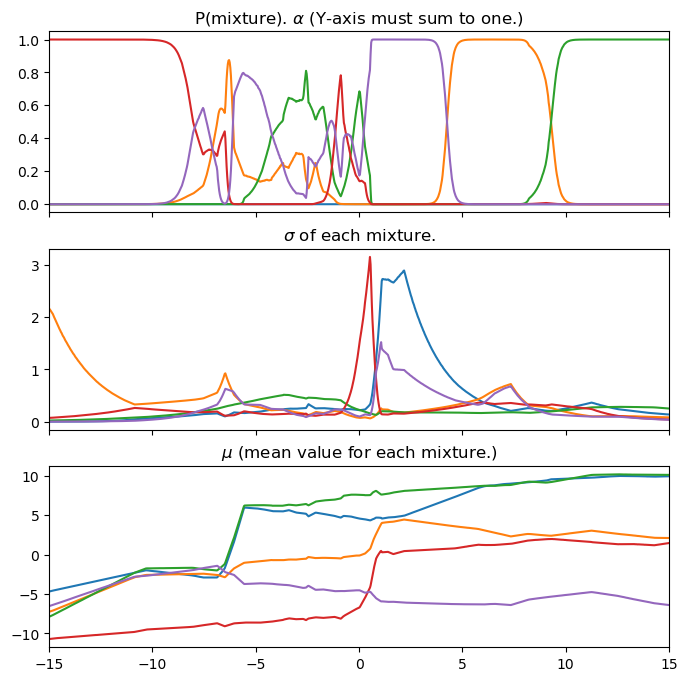

In [92]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(8,8))
ax1.plot(x_test_data, α_data)
ax1.set_title(r'P(mixture). $\alpha$ (Y-axis must sum to one.)')
ax2.plot(x_test_data, σ_data)
ax2.set_title(r'$\sigma$ of each mixture.')
ax3.plot(x_test_data, μ_data)
ax3.set_title(r'$\mu$ (mean value for each mixture.)')
plt.xlim([-15,15])
plt.show()

In [93]:
def gumbel_sample(x, axis=1):
    z = np.random.gumbel(loc=0, scale=1, size=x.shape)
    return (np.log(x) + z).argmax(axis=axis)

k = gumbel_sample(α_data)
indices = (np.arange(n_samples), k)
rn = np.random.randn(n_samples)
sampled = rn * σ_data[indices] + μ_data[indices]


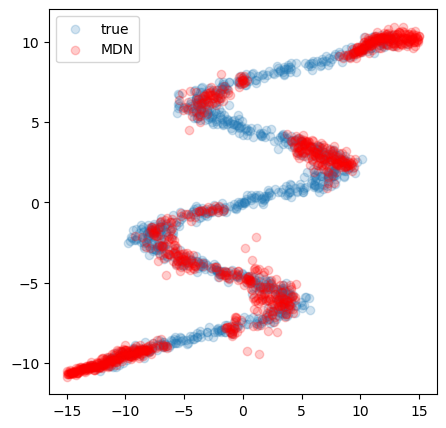

In [97]:
plt.figure(figsize=(5, 5))
plt.scatter(mdn_x_data, mdn_y_data, alpha=0.2, label='true')
plt.scatter(x_test_data, sampled, alpha=0.2, color='red', label='MDN')
plt.legend()
